In [13]:
#%matplotlib inline
%matplotlib widget
import numpy as np
import rebound
from matplotlib import pyplot as plt
from IPython import display
import pandas as pd

## Orbital parameters:

| Object   |    Mass               | Radius                          | $a$  (au)      |  $e$                   | $\omega$ (deg)      | $i$ (deg)         |
| :------: | :------:              | :-------:                       | :-----:        | :-----:                | :-----:             | :-----:           |
| PDS 70   | $0.76±0.02$ $M_\odot$ |  $1.26 \pm 0.15 R_{\odot}$      |  --            |       --               | --                  | --                |
| PDS 70 b | $3 ± 1 M_{Jup}$       | $2.72^{+0.20}_{-1.9} R_{Jup}$   | $20 ± 2 $      | $0.19^{+0.15}_{-0.09}$ | $148 ± 31$          | $ 140^{+ 7}_{-6}$ |
| PDS 70 c | $2 ± 1$   $M_{Jup}$   |  $2.04^{+0.61}_{-0.45} R_{Jup}$ | $34^{+6}_{-3}$ |$ 0.11^{+0.12}_{-0.06}$ | $ 136^{+50}_{- 58}$ | $132 ± 7$         |

see https://exoplanetarchive.ipac.caltech.edu/overview/PDS%2070#star_PDS-70_collapsible for more details.

## Setting up...

In [19]:
sim = rebound.Simulation()
sim.units = ['msun', 'yr', 'AU']

dtor = np.pi/180 #degree to radian
jtos = 0.000954265748  #jupiter mass to solar mass

#Using Trevascus et al 2025 vals

a_b, a_c, a_d = 21.1, 35.3, 10.7
e_b, e_c, e_d = 0.131, 0.033, 0.25
w_b, w_c, w_d = 191.4, 63, 29
i_b, i_c, i_d = 128.7, 128.5, 151
Omega_b, Omega_c, Omega_d = 174.3, 159.8, 144
m_b, m_c, m_d = 0.7, 2.4, 0.4

sim.add(m = 0.965, x=0, y= 0, z = 0)
sim.add(m = m_d*jtos, a = a_d, e = e_d, f=np.random.rand()*2.*np.pi, inc = (i_d-128.3)*dtor, omega = w_d*dtor, Omega =  Omega_d*dtor)
sim.add(m = m_b*jtos, a = a_b, e = e_b, f=np.random.rand()*2.*np.pi, omega = w_b*dtor, inc = (i_b-128.3)*dtor, Omega = Omega_b*dtor)
sim.add(m = m_c*jtos, a = a_c, e = e_c, f=np.random.rand()*2.*np.pi, omega = w_c*dtor, inc = (i_c-128.3)*dtor, Omega = Omega_c*dtor)
sim.move_to_com()
sim.save_to_file('initial.bin')

sim.integrate(1e6)
sim.orbits()

[<rebound.Orbit instance, a=10.774366361990678 e=0.22846315383472762 inc=0.33375762877232845 Omega=-2.97419373350407 omega=4.789545886822683 f=4.7652466946468>,
 <rebound.Orbit instance, a=20.941133279808746 e=0.17595988863438872 inc=0.04961131989164157 Omega=0.17371911317295913 omega=6.173525527409148 f=3.401419900848846>,
 <rebound.Orbit instance, a=35.31235535757331 e=0.02735531139550919 inc=0.028453773550169828 Omega=2.10229370912492 omega=0.6302372589564325 f=3.248118110177878>]

### Defining a DataFrame with parameter values to use for comparison for later. Here, all values are for t = 0.

In [22]:
# planet_names = {1: "PDS 70 b", 2: "PDS 70 c"}

# initial_orbits = sim.orbits()
# text_df = pd.DataFrame([{
#     'Planet': planet_names[i+1], 
#     'a': round(orbit.a,2),
#     'e': round(orbit.e,2),
#     'inc': round(orbit.inc,2),
#     'Omega': round(orbit.Omega,2),
#     'omega': round(orbit.omega,2),
#     'f': round(orbit.f,2)
# } for i, orbit in enumerate(initial_orbits)])
# text_df['time'] = sim.t

### Plotting the simulation at t = 0, along with the orbital elements:

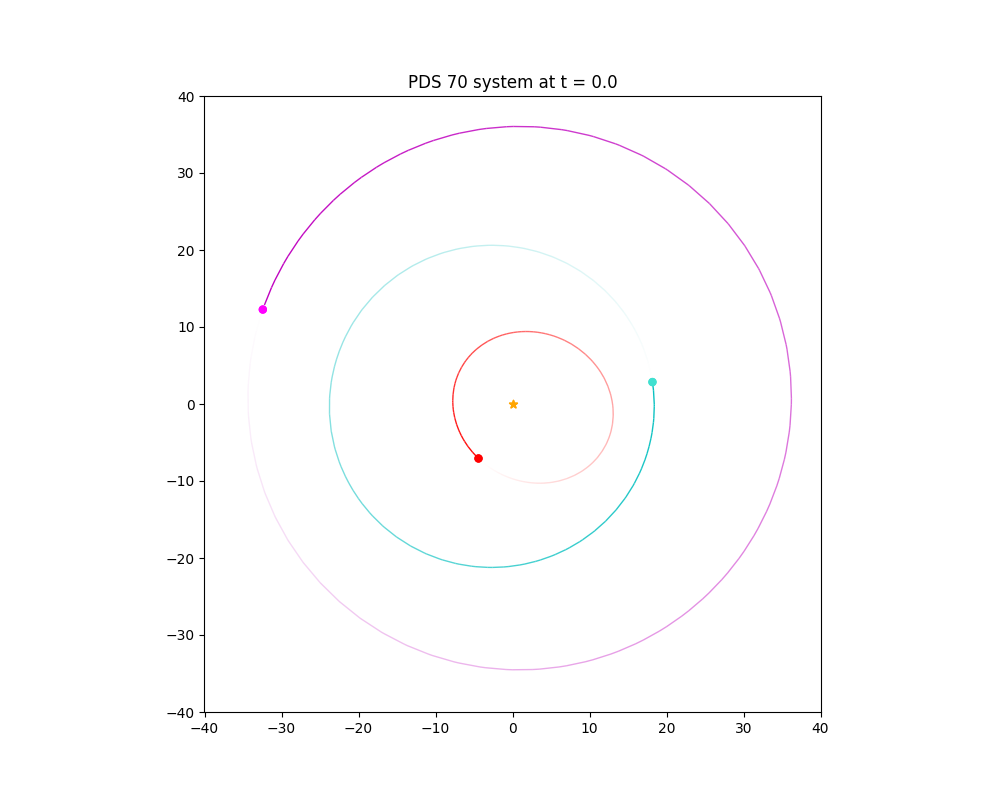

In [6]:
#fig, axs = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [4 , 1]})
fig, axs = plt.subplots(figsize=(10,8))

op = rebound.OrbitPlot(sim, fig=fig, ax=axs, color=True, unitlabel="[au]", )
op.primary.set_color("orange")
op.particles.set_color(["red", "turquoise", 'magenta'])

#axs[1].axis('off')

# table = axs[1].table(cellText=text_df.values, colLabels=text_df.columns, loc='center', cellLoc='center', rowLoc='center',
#                      cellColours=[['red', 'red', 'red', 'red', 'red', 'red', 'red', 'red'],
#                                 ['turquoise', 'turquoise', 'turquoise', 'turquoise', 'turquoise', 'turquoise', 'turquoise', 'turquoise']],
#                      alpha = 0.1, edges = 'BRTL')
axs.set_aspect('equal')
axs.set_xlim(-40, 40)
axs.set_ylim(-40, 40)

axs.set_title(f'PDS 70 system at t = {sim.t}')
#axs[1].set_title(f'Orbital parameters at t = {sim.t}')
plt.show()

### Integrating forward 1 M years

In [12]:
sim = rebound.Simulation('initial.bin')
sim.integrate(5e6)
sim.orbits()

[<rebound.Orbit instance, a=11.003976348966756 e=0.0534607752306565 inc=0.27655949749098996 Omega=1.1783737561397172 omega=1.7373717194049831 f=3.5615040423924462>,
 <rebound.Orbit instance, a=20.000250568263283 e=0.2242713693311385 inc=0.19281090635314616 Omega=3.13076103640577 omega=0.009370733377854101 f=2.5364163016464296>,
 <rebound.Orbit instance, a=35.715972293585345 e=0.023641046171231778 inc=0.0026799200946745426 Omega=-2.0620072204401994 omega=1.688380152973095 f=0.7030781600789942>]

### Grabbing parameters again, this time for t = 1e6 yr.

In [7]:
more_orbits = sim.orbits()
text_df_2 = pd.DataFrame([{
    'Planet': planet_names[i+1], 
    'a (au)': round(orbit.a,2),
    'e': round(orbit.e,2),
    'inc (deg)': round(orbit.inc/dtor,2),
    'Omega (deg)': round(orbit.Omega/dtor,2),
    'omega (deg)': round(orbit.omega/dtor,2),
    'f': round(orbit.f,2)
} for i, orbit in enumerate(more_orbits)])
text_df_2['time (yr)'] = sim.t
text_df_2['time (yr)'] = text_df_2['time (yr)'].apply(lambda x: f'{x:.2e}')

### Plotting system at 1e6 years

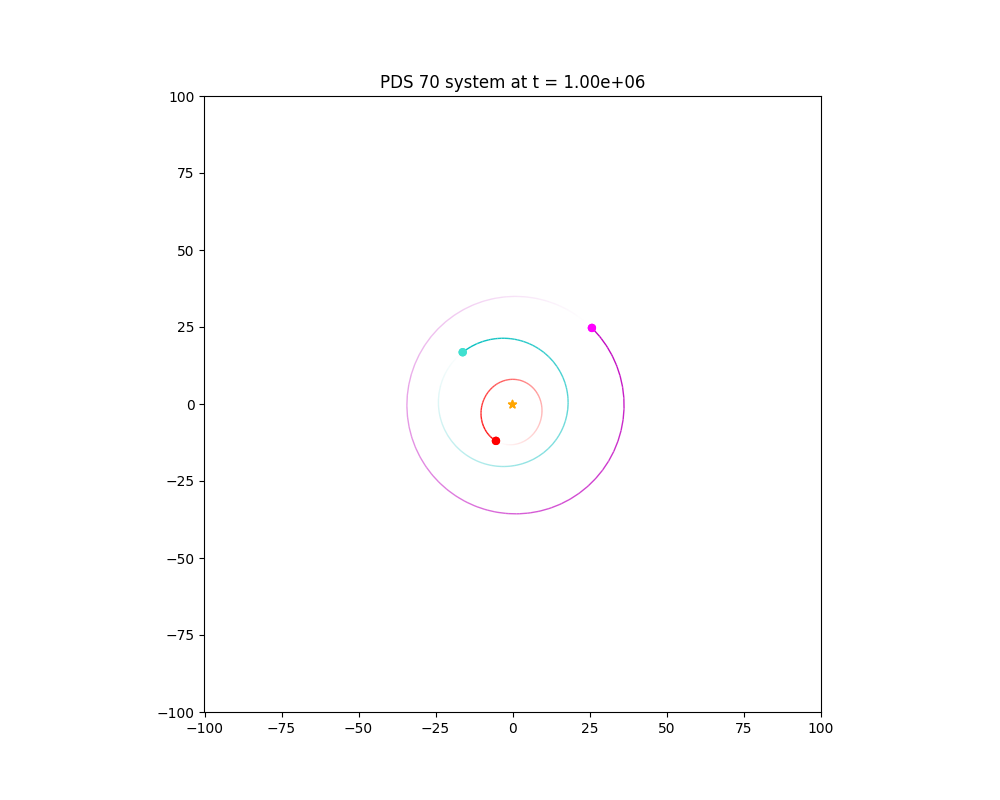

In [8]:
fig, axs = plt.subplots( figsize=(10, 8))

op = rebound.OrbitPlot(sim, fig=fig, ax=axs, color=True, unitlabel="[au]", )
op.primary.set_color("orange")
op.particles.set_color(["red", "turquoise", 'magenta'])


# table = axs[1].table(cellText=text_df_2.values, colLabels=text_df_2.columns, loc='center', cellLoc='center', rowLoc='center',
#                      cellColours=[['red']*8, ['turquoise']*8], alpha = 0.1, edges = 'BRTL')

axs.set_aspect('equal')
axs.set_xlim(-100, 100)

axs.set_ylim(-100, 100)
axs.set_title(f'PDS 70 system at t = {sim.t:.2e}')
plt.show()

In [34]:
sim.integrate(2e6)
sim.orbits()

[<rebound.Orbit instance, a=9.28854814737272 e=0.41621669206170525 inc=0.5725620121834817 Omega=3.0595461584675547 omega=0.09831768616653047 f=3.054879753936312>,
 <rebound.Orbit instance, a=21.631055433376808 e=0.08046569082751537 inc=0.06458014335289165 Omega=-3.0050893427589545 omega=0.6871304268252239 f=0.9617687185667947>,
 <rebound.Orbit instance, a=35.03038211927764 e=0.0345192476686206 inc=0.052003211663619466 Omega=0.3195938560136926 omega=4.937878404659466 f=5.138471364933247>]

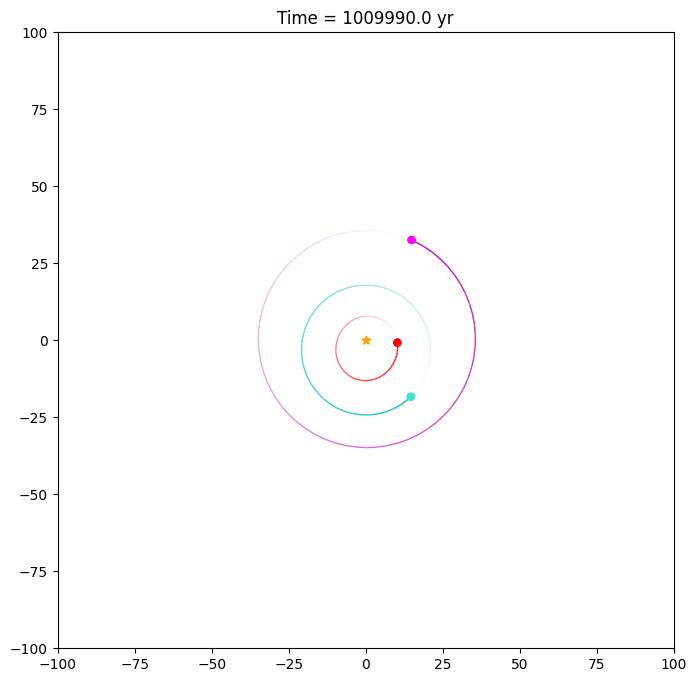

In [9]:


nframe = 1000
framestep = 10

fig = op.fig
for i in range(nframe):
    op.sim.integrate(sim.t + framestep) # timestep the sim
    display.display(plt.gcf())          # start to...
    display.clear_output(wait=True)     # ...clean up old plot
    plt.title(f'Time = {sim.t} yr')
    op.update()


Larger $a$, mean everything else.

In [10]:
sim2 = rebound.Simulation()
sim2.units = ['msun', 'yr', 'AU']
sim2.move_to_com()


In [11]:
dtor = np.pi/180 #degree to radian
jtos = 0.000954265748  #jupiter mass to solar mass

sim2.add(m = 0.76)
sim2.add(m = 3*jtos, a = 20, e = 0.19, omega = 148*dtor, inc = 140*dtor, hash="PDS b")
sim2.add(m = 1*jtos, a = 34, e = 0.11, omega = 136*dtor, inc = 132*dtor, hash="PDS c")

sim2.move_to_com()
sim2.status()



---------------------------------
REBOUND version:     	4.4.6
REBOUND built on:    	Dec 30 2024 23:42:23
Number of particles: 	3
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x7fcc6ad6b740, m=0.76 x=0.07875067186140107 y=0.04225113173680716 z=-0.040224041959126614 vx=0.0038705070119776142 vy=-0.004258452431868522 vz=0.0037449810803390315>
<rebound.particle.Particle object at 0x7fcc6ad6ba40, m=0.002862797244 x=-13.659628485872698 y=-6.534004532477404 z=5.47790966041052 vx=-0.7843006997732048 vy=0.9619822046579667 vz=-0.8070271979122347>
<rebound.particle.Particle object at 0x7fcc6ad6b740, m=0.000954265748 x=-21.740027738315675 y=-14.047795365399217 z=15.601657338571906 vx=-0.7296619927774919 vy=0.5055864626382935 vz=-0.5615106527343109>
---------------------------------
The following fields have non-default values:
G:
< 1.000000e+00
---
> 3.947693e+01
N:
< 0


In [12]:
planet_names = {1: "PDS 70 b", 2: "PDS 70 c"}

initial_orbits = sim2.orbits()
df = pd.DataFrame([{
    'Planet': planet_names[i+1], 
    'Mass (M_J)' : sim2.particles[i+1].m/jtos,
    'a (au)': orbit.a,
    'e': orbit.e,
    'inc (deg)': np.degrees(orbit.inc),
    'omega (deg)': np.degrees(orbit.omega),
    'Omega (deg)': np.degrees(orbit.Omega),
    'f': orbit.f
} for i, orbit in enumerate(initial_orbits)])
df['time (yr)'] = 0

df

,Planet,Mass (M_J),a (au),e,inc (deg),omega (deg),Omega (deg),f,time (yr)
0,PDS 70 b,3.0,20.0,0.19,140.0,148.0,0.0,6.283185e+00,0
1,PDS 70 c,1.0,34.0,0.11,132.0,136.0,0.0,8.881784e-16,0


In [13]:

  # Add time column for reference

# Run simulation
times = [0, 1e3, 1e6, 5e6]

for t in times[1:]:
    print(t)
    sim2.integrate(t)
    orbits = sim2.orbits()
    
    new_data = [{
      'Planet': planet_names[i+1], 
      'Mass (M_J)' : sim2.particles[i+1].m/jtos,
      'a (au)': orbit.a,
      'e': orbit.e,
      'inc (deg)': np.degrees(orbit.inc),
      'omega (deg)': np.degrees(orbit.omega),
      'Omega (deg)': np.degrees(orbit.Omega),
      'f': orbit.f,
      'time (yr)': t
    } for i, orbit in enumerate(orbits)]
    
    df = pd.concat([df, pd.DataFrame(new_data)], ignore_index=True)

final_orbits = df[df['time (yr)'] == max(times)]
initial_orbits = df[df['time (yr)'] == 0]

# print("Initial orbits:")
# print(initial_orbits)
# print("\nFinal orbits:")
# print(final_orbits)


1000.0
1000000.0
5000000.0


In [14]:
df_b = df.iloc[::2]
df_c = df.iloc[1::2]

df_final = pd.concat([df_b, df_c], ignore_index=True)

df_final = df_final.round(2)

df_final

,Planet,Mass (M_J),a (au),e,inc (deg),omega (deg),Omega (deg),f,time (yr)
0,PDS 70 b,3.0,20.00,0.19,140.00,148.00,0.00,6.28,0.0
1,PDS 70 b,3.0,19.96,0.19,140.02,153.07,-0.32,4.24,1000.0
2,PDS 70 b,3.0,16.64,0.11,139.96,119.75,1.33,5.39,1000000.0
3,PDS 70 b,3.0,16.64,0.11,139.96,119.75,1.33,3.03,5000000.0
4,PDS 70 c,1.0,34.00,0.11,132.00,136.00,0.00,0.00,0.0
5,PDS 70 c,1.0,34.14,0.12,131.96,131.72,0.63,3.09,1000.0
6,PDS 70 c,1.0,-1466.30,1.02,133.22,283.41,-2.10,2.96,1000000.0
7,PDS 70 c,1.0,-1466.30,1.02,133.22,283.41,-2.10,2.97,5000000.0


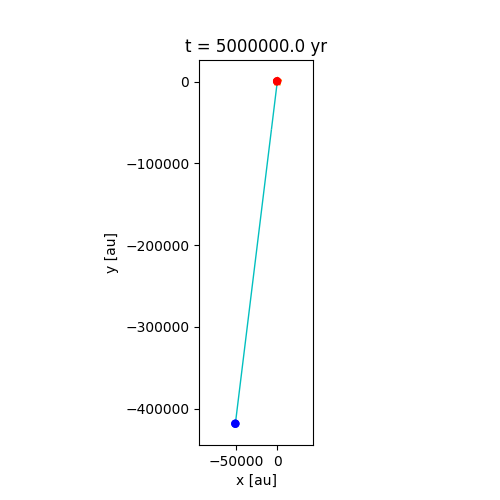

In [15]:
sim2.move_to_com()
op = rebound.OrbitPlot(sim2, color=True, unitlabel="[au]", )
op.primary.set_color("orange")
op.particles.set_color(["red", "blue"])

ax = plt.gca()
ax.set_aspect('equal')
# ax.set_xlim(-40, 40)
# ax.set_ylim(-40, 40)
ax.set_title(f't = {sim2.t} yr')
plt.show()

In [16]:
sim2.integrate(1e7)
sim2.orbits()

[<rebound.Orbit instance, a=16.63597503879387 e=0.10728835093530237 inc=2.442710680934913 Omega=0.02329207347643011 omega=2.090117511644319 f=6.081199725952978>,
 <rebound.Orbit instance, a=-1466.2977415865707 e=1.0156153978977558 inc=2.3251800284745956 Omega=-0.036716008671942225 omega=4.94646839901179 f=2.965813631561163>]

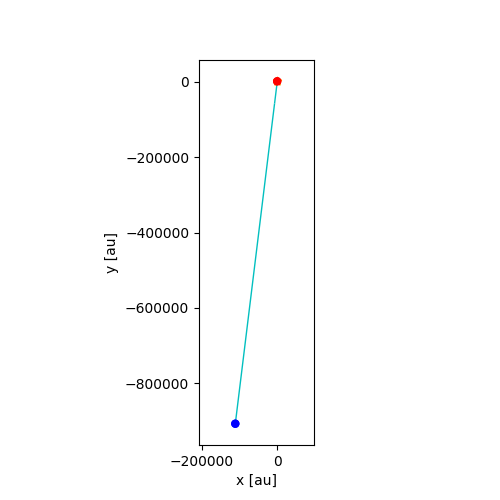

In [17]:
sim2.move_to_com()
op = rebound.OrbitPlot(sim2, color=True, unitlabel="[au]", )
op.primary.set_color("orange")
op.particles.set_color(["red", "blue"])

nframe = 220
framestep = 1

fig = op.fig

for i in range(nframe):
    op.sim.integrate(sim2.t + framestep*2) # timestep the sim
    display.display(plt.gcf())          # start to...
    display.clear_output(wait=True)     # ...clean up old plot
    op.update() 

In [18]:
sim2.t

10000440.0

In [19]:
many_years_later = [{
    'Planet': planet_names[i+1],
    'a': orbit.a,
    'e': orbit.e,
    'inc': orbit.inc,
    'Omega': orbit.Omega,
    'omega': orbit.omega,
    'f': orbit.f,
    'time': sim2.t
} for i, orbit in enumerate(sim2.orbits())]

df = pd.concat([df, pd.DataFrame(many_years_later)], ignore_index=True)
df

,Planet,Mass (M_J),a (au),e,inc (deg),omega (deg),Omega (deg),f,time (yr),a,inc,Omega,omega,time
0,PDS 70 b,3.0,20.000000,0.190000,140.000000,148.000000,0.000000,6.283185e+00,0.0,NaN,NaN,NaN,NaN,NaN
1,PDS 70 c,1.0,34.000000,0.110000,132.000000,136.000000,0.000000,8.881784e-16,0.0,NaN,NaN,NaN,NaN,NaN
2,PDS 70 b,3.0,19.963561,0.187079,140.019685,153.073760,-0.320096,4.244732e+00,1000.0,NaN,NaN,NaN,NaN,NaN
3,PDS 70 c,1.0,34.142595,0.120037,131.959471,131.718447,0.625853,3.088091e+00,1000.0,NaN,NaN,NaN,NaN,NaN
4,PDS 70 b,3.0,16.635975,0.107288,139.957013,119.754912,1.334538,5.386031e+00,1000000.0,NaN,NaN,NaN,NaN,NaN
5,PDS 70 c,1.0,-1466.297742,1.015615,133.223002,283.411763,-2.103672,2.959167e+00,1000000.0,NaN,NaN,NaN,NaN,NaN
6,PDS 70 b,3.0,16.635975,0.107288,139.957013,119.754912,1.334538,3.033841e+00,5000000.0,NaN,NaN,NaN,NaN,NaN
7,PDS 70 c,1.0,-1466.297742,1.015615,133.223002,283.411763,-2.103672,2.965586e+00,5000000.0,NaN,NaN,NaN,NaN,NaN
8,PDS 70 b,NaN,NaN,0.107288,NaN,NaN,NaN,3.857829e+00,NaN,16.635975,2.442711,0.023292,2.090118,10000440.0
9,PDS 70 c,NaN,NaN,1.015615,NaN,NaN,NaN,2.965814e+00,NaN,-1466.297742,2.325180,-0.036716,4.946468,10000440.0


In [3]:
import numpy as np
import astropy.units as u
import astropy.constants as const

def r_hill(a, m):
    M_star = 0.965 * const.M_sun
    return a * (m / (3*M_star))**(1/3)

r_hill(35.3*u.au, 3*const.M_jup), r_hill(21.1*u.au, 4*const.M_jup)

(<Quantity 3.51726591 AU>, <Quantity 2.31397786 AU>)

## Semi-active particles

In [8]:
#%matplotlib widget
import numpy as np
import rebound
from matplotlib import pyplot as plt
from IPython import display
import pandas as pd
import time

sim = rebound.Simulation()
sim.units = ['msun', 'yr', 'AU']

dtor = np.pi/180 #degree to radian
jtos = 0.000954265748  #jupiter mass to solar mass

#Using Trevascus et al 2025 vals

a_b, a_c, a_d = 21.1, 35.3, 10.7
e_b, e_c, e_d = 0.131, 0.033, 0.25
w_b, w_c, w_d = 191.4, 63, 29
i_b, i_c, i_d = 128.7, 128.5, 151
Omega_b, Omega_c, Omega_d = 174.3, 159.8, 144
m_b, m_c, m_d = 0.7, 2.4, 0.4

sim.add(m = 0.965, x=0, y= 0, z = 0)
sim.add(m = m_d*jtos, a = a_d, e = e_d, f=np.random.rand()*2.*np.pi, inc = (i_d-128.3)*dtor, omega = w_d*dtor, Omega =  Omega_d*dtor)
sim.add(m = m_b*jtos, a = a_b, e = e_b, f=np.random.rand()*2.*np.pi, omega = w_b*dtor, inc = (i_b-128.3)*dtor, Omega = Omega_b*dtor)
sim.add(m = m_c*jtos, a = a_c, e = e_c, f=np.random.rand()*2.*np.pi, omega = w_c*dtor, inc = (i_c-128.3)*dtor, Omega = Omega_c*dtor)
sim.move_to_com()

t_start = time.time()
N_testparticle = 200
a_initial = np.linspace(20, 40, N_testparticle)

for a in a_initial:
    sim.add(a=a,f=np.random.rand()*2.*np.pi, m=1e-7)

sim.N_active = 4
sim.testparticle_type = 1
sim.integrate(1e3)

t_end = time.time()

print(f'that took {(t_end - t_start)/60} min')

KeyboardInterrupt: 

In [ ]:
#%matplotlib widget
import numpy as np
import rebound
from matplotlib import pyplot as plt
from IPython import display
import pandas as pd
import time

sim = rebound.Simulation()
sim.units = ['msun', 'yr', 'AU']

dtor = np.pi/180 #degree to radian
jtos = 0.000954265748  #jupiter mass to solar mass

#Using Trevascus et al 2025 vals

a_b, a_c, a_d = 21.1, 35.3, 10.7
e_b, e_c, e_d = 0.131, 0.033, 0.25
w_b, w_c, w_d = 191.4, 63, 29
i_b, i_c, i_d = 128.7, 128.5, 151
Omega_b, Omega_c, Omega_d = 174.3, 159.8, 144
m_b, m_c, m_d = 0.7, 2.4, 0.4

sim.add(m = 0.965, x=0, y= 0, z = 0)
sim.add(m = m_d*jtos, a = a_d, e = e_d, f=np.random.rand()*2.*np.pi, inc = (i_d-128.3)*dtor, omega = w_d*dtor, Omega =  Omega_d*dtor)
sim.add(m = m_b*jtos, a = a_b, e = e_b, f=np.random.rand()*2.*np.pi, omega = w_b*dtor, inc = (i_b-128.3)*dtor, Omega = Omega_b*dtor)
sim.add(m = m_c*jtos, a = a_c, e = e_c, f=np.random.rand()*2.*np.pi, omega = w_c*dtor, inc = (i_c-128.3)*dtor, Omega = Omega_c*dtor)
sim.move_to_com()

t_start = time.time()
N_testparticle = 200
a_initial = np.linspace(20, 40, N_testparticle)

for a in a_initial:
    sim.add(a=a,f=np.random.rand()*2.*np.pi)

sim.N_active = 4
sim.integrate(1e3)

t_end = time.time()

print(f'that took {(t_end - t_start)/60} min')

that took 0.3856690526008606 min


In [2]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u

a_b, a_c, a_d = 21.1, 35.3, 10.7
e_b, e_c, e_d = 0.131, 0.033, 0.25
w_b, w_c, w_d = 191.4, 63, 29
i_b, i_c, i_d = 128.7, 128.5, 151
Omega_b, Omega_c, Omega_d = 174.3, 159.8, 144
m_b, m_c, m_d = 0.7, 2.4, 0.4
jtos = const.M_jup / const.M_sun
dtor = np.pi / 180

sim = rebound.Simulation()
sim.units = ['msun', 'yr', 'AU']

sim.add(m = 0.965, x=0, y= 0, z = 0, hash='star')
sim.add(m = m_d*jtos, a = a_d, e = e_d, f=np.random.rand()*2.*np.pi,
        inc = (i_d-128.3)*dtor, omega = w_d*dtor, Omega =  Omega_d*dtor, hash='pd')
sim.add(m = m_b*jtos, a = a_b, e = e_b, f=np.random.rand()*2.*np.pi,
        omega = w_b*dtor, inc = (i_b-128.3)*dtor, Omega = Omega_b*dtor, hash = 'pb')
sim.add(m = m_c*jtos, a = a_c, e = e_c, f=np.random.rand()*2.*np.pi,
        omega = w_c*dtor, inc = (i_c-128.3)*dtor, Omega = Omega_c*dtor, hash = 'pc')

In [18]:
sim.integrate(1e6)
print((np.sqrt(sim.particles[1].vx**2 + sim.particles[1].vy**2)* u.AU / u.yr ).to('km/s'))

9.571781327991948 km / s


## Things we need to implement gas drag:

For gas surface density, $\Sigma$:
- position of the outer disk edge
- $\alpha$ (for viscous transport) - usually set to $10^{-3}$ in PDS 70 papers
- $\dot{M_0}$ (disc accretion rate)
- $\nu$ kinematic velocity
- temperature
- mean molecular weight

In [14]:
const.m_p

<<class 'astropy.constants.codata2018.CODATA2018'> name='Proton mass' value=1.67262192369e-27 uncertainty=5.1e-37 unit='kg' reference='CODATA 2018'>

In [ ]:
def gas_drag_force(M_dot, alpha, r, r_out, mu, z, solid_rho, R_pl):

    '''first, compute gas density as a function of z'''
    r = r * u.AU
    r_out = r_out * u.AU
    M_star = 0.965*const.M_sun
    k_B = const.k_B
    Omega = np.sqrt(const.G * M_star / r**3)
    T = 150 * 0.35**(2/7) * 0.965**(-1/7) * (r/u.AU)**(-3/7) * u.K
    c_s = np.sqrt(k_B*T/(mu*const.m_p))
    H = c_s / Omega
    print(H.to('m'))
    nu = alpha * Omega * H**2

    surface_density = M_dot / (3 * np.pi * nu) * np.exp(-r/r_out)

    
    gas_density = surface_density / (np.sqrt(2*np.pi) * H) * np.exp(-(z*u.AU)**2 / (2 * H**2))

    print(gas_density.to('kg/m^3'))

    lg = 5e-6 / gas_density
    Re = 4 * R_pl * 3000 / (c_s * lg)
    C_D = 24/Re * (1+0.27*Re)**(0.43) + 0.47*(1-np.exp(-0.04*Re**(0.38)))
    v_th = np.sqrt(8/np.pi) * c_s

    less_than1 = 3/8*3000 / v_th * C_D * Re
    print(less_than1)

    '''next, compute the stopping time, assuming the min of the function in Eriksson et al. is 1!'''
    ts = (gas_density/solid_rho * v_th/R_pl)**(-1)

    v_pl = 1
    v_gas = 1
    a = -1/ts * (v_pl - v_gas)
    return 

gas_drag_force(1e-10, 1e-3, 21, 87, 2.33, 0.1, 1000, 100000 )


161193436343.7027 m


UnitConversionError: 'kg(3/2) m3 / (AU3 J(3/2) s2)' and 'kg / m3' (mass density) are not convertible